# 🛒 Dark Store Geospatial Network Optimization
### Quick Commerce Analytics — Blinkit · Zepto · Swiggy Instamart

---

**What this notebook does:**
1. Generates 501,000 synthetic delivery orders across 3 Indian cities
2. Maps each order to its nearest dark store (using Haversine distance)
3. Finds optimal store placement using K-Means clustering
4. Simulates the impact of moving a store by 500 meters
5. Identifies underserved high-demand zones
6. Builds an interactive map (your portfolio link)
7. Exports CSVs ready for Tableau

**How to use this notebook:**
- Click on any cell and press **Shift + Enter** to run it
- Run cells **in order from top to bottom**
- Each cell shows expected output below it

---

## CELL 1 — Install Libraries
Run this once. It installs everything needed.
If you already ran `pip install` in terminal, you can skip this cell.

In [ ]:
# Run this cell once to install all required libraries
# Expected output: lots of text ending in 'Successfully installed...'
import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'pandas', 'numpy', 'scikit-learn', 'folium',
    'matplotlib', 'seaborn', 'faker', '--quiet'
])
print('All libraries installed successfully')

✓ All libraries installed successfully


## CELL 2 — Import Libraries
This loads all the tools we need into memory.
**Expected output:** `✓ All imports successful`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
from datetime import datetime, timedelta
import warnings, os, time
warnings.filterwarnings('ignore')

# Create output folders if they don't exist
for folder in ['data/raw', 'data/processed', 'outputs']:
    os.makedirs(folder, exist_ok=True)

np.random.seed(42)
print('All imports successful')
print('Output folders ready')

All imports successful
Output folders ready


## CELL 3 — City & Zone Configuration
We define real neighbourhoods for each city with:
- Their actual lat/lng coordinates
- `weight` = how many orders come from that area (higher = busier)
- `spread_km` = how spread out delivery addresses are in that zone

**Expected output:** `Loaded 3 cities with 35 zones total`

In [3]:
CITY_ZONES = {
    'Bengaluru': [
        {'area': 'Koramangala',     'lat': 12.9352, 'lng': 77.6245, 'weight': 0.14, 'spread_km': 0.8},
        {'area': 'HSR Layout',      'lat': 12.9116, 'lng': 77.6370, 'weight': 0.10, 'spread_km': 0.7},
        {'area': 'Indiranagar',     'lat': 12.9784, 'lng': 77.6408, 'weight': 0.11, 'spread_km': 0.6},
        {'area': 'BTM Layout',      'lat': 12.9166, 'lng': 77.6101, 'weight': 0.09, 'spread_km': 0.7},
        {'area': 'Whitefield',      'lat': 12.9698, 'lng': 77.7499, 'weight': 0.08, 'spread_km': 1.2},
        {'area': 'Electronic City', 'lat': 12.8456, 'lng': 77.6603, 'weight': 0.07, 'spread_km': 1.0},
        {'area': 'Marathahalli',    'lat': 12.9591, 'lng': 77.6974, 'weight': 0.09, 'spread_km': 0.8},
        {'area': 'JP Nagar',        'lat': 12.9077, 'lng': 77.5851, 'weight': 0.08, 'spread_km': 0.8},
        {'area': 'Jayanagar',       'lat': 12.9250, 'lng': 77.5938, 'weight': 0.07, 'spread_km': 0.6},
        {'area': 'Malleshwaram',    'lat': 13.0035, 'lng': 77.5640, 'weight': 0.06, 'spread_km': 0.6},
        {'area': 'Sarjapur Road',   'lat': 12.9010, 'lng': 77.6850, 'weight': 0.06, 'spread_km': 0.9},
        {'area': 'Yelahanka',       'lat': 13.1007, 'lng': 77.5963, 'weight': 0.05, 'spread_km': 1.1},
    ],
    'Mumbai': [
        {'area': 'Bandra West',   'lat': 19.0596, 'lng': 72.8295, 'weight': 0.13, 'spread_km': 0.5},
        {'area': 'Andheri West',  'lat': 19.1136, 'lng': 72.8697, 'weight': 0.12, 'spread_km': 0.7},
        {'area': 'Juhu',          'lat': 19.1075, 'lng': 72.8263, 'weight': 0.09, 'spread_km': 0.5},
        {'area': 'Powai',         'lat': 19.1176, 'lng': 72.9060, 'weight': 0.10, 'spread_km': 0.7},
        {'area': 'Lower Parel',   'lat': 18.9988, 'lng': 72.8302, 'weight': 0.10, 'spread_km': 0.5},
        {'area': 'Worli',         'lat': 19.0176, 'lng': 72.8181, 'weight': 0.08, 'spread_km': 0.5},
        {'area': 'Malad West',    'lat': 19.1863, 'lng': 72.8484, 'weight': 0.08, 'spread_km': 0.8},
        {'area': 'Goregaon East', 'lat': 19.1663, 'lng': 72.8526, 'weight': 0.07, 'spread_km': 0.7},
        {'area': 'Chembur',       'lat': 19.0522, 'lng': 72.8994, 'weight': 0.07, 'spread_km': 0.7},
        {'area': 'Santacruz',     'lat': 19.0896, 'lng': 72.8436, 'weight': 0.08, 'spread_km': 0.5},
        {'area': 'Thane West',    'lat': 19.1973, 'lng': 72.9614, 'weight': 0.08, 'spread_km': 1.0},
    ],
    'Delhi NCR': [
        {'area': 'Gurugram Sector 29',  'lat': 28.4744, 'lng': 77.0266, 'weight': 0.11, 'spread_km': 0.8},
        {'area': 'Gurugram Cyber City', 'lat': 28.4950, 'lng': 77.0880, 'weight': 0.10, 'spread_km': 0.7},
        {'area': 'Noida Sector 18',     'lat': 28.5708, 'lng': 77.3219, 'weight': 0.09, 'spread_km': 0.7},
        {'area': 'Noida Sector 62',     'lat': 28.6272, 'lng': 77.3687, 'weight': 0.08, 'spread_km': 0.8},
        {'area': 'Lajpat Nagar',        'lat': 28.5672, 'lng': 77.2434, 'weight': 0.09, 'spread_km': 0.6},
        {'area': 'Saket',               'lat': 28.5244, 'lng': 77.2167, 'weight': 0.08, 'spread_km': 0.6},
        {'area': 'South Delhi GK1',     'lat': 28.5494, 'lng': 77.2311, 'weight': 0.08, 'spread_km': 0.5},
        {'area': 'Connaught Place',     'lat': 28.6315, 'lng': 77.2167, 'weight': 0.07, 'spread_km': 0.5},
        {'area': 'Dwarka Sector 10',    'lat': 28.5823, 'lng': 77.0431, 'weight': 0.07, 'spread_km': 0.8},
        {'area': 'Rohini Sector 7',     'lat': 28.7041, 'lng': 77.1025, 'weight': 0.07, 'spread_km': 0.9},
        {'area': 'Vasant Kunj',         'lat': 28.5216, 'lng': 77.1569, 'weight': 0.07, 'spread_km': 0.7},
        {'area': 'Greater Noida',       'lat': 28.4744, 'lng': 77.5040, 'weight': 0.09, 'spread_km': 1.2},
    ],
}

total_zones = sum(len(z) for z in CITY_ZONES.values())
print(f'Loaded {len(CITY_ZONES)} cities with {total_zones} zones total')
for city, zones in CITY_ZONES.items():
    print(f'   {city}: {len(zones)} zones')

Loaded 3 cities with 35 zones total
   Bengaluru: 12 zones
   Mumbai: 11 zones
   Delhi NCR: 12 zones


## CELL 4 — Generate 501,000 Delivery Orders
This creates your dataset. Each row = one delivery order.

**Expected output:**
```
[Bengaluru] done in ~1s
[Mumbai] done in ~1s  
[Delhi NCR] done in ~1s
Total orders: 501,000
```

In [ ]:
BRANDS        = ['Blinkit', 'Zepto', 'Swiggy Instamart']
BRAND_WEIGHTS = [0.40,       0.32,    0.28]

HOUR_WEIGHTS = np.array([
    0.5, 0.3, 0.2, 0.2, 0.3, 0.5,   # midnight–5am: almost no orders
    0.8, 1.2, 2.0, 1.8, 1.5, 1.5,   # 6am–11am: morning peak
    2.2, 2.0, 1.5, 1.3, 1.4, 1.6,   # 12pm–5pm: lunch + afternoon
    1.8, 2.5, 2.8, 2.2, 1.5, 0.8    # 6pm–11pm: evening peak
])
HOUR_WEIGHTS = HOUR_WEIGHTS / HOUR_WEIGHTS.sum()

def generate_city_orders(city_name, zones, n_orders=167000):
    t0 = time.time()
    print(f'  [{city_name}] Generating {n_orders:,} orders...', end=' ', flush=True)
    n = n_orders
    
    # Pick a zone for each order based on density weights
    weights = np.array([z['weight'] for z in zones], dtype=float)
    weights /= weights.sum()
    zone_idx = np.random.choice(len(zones), size=n, p=weights)
    
    # Get zone attributes for all orders at once (vectorized = fast)
    c_lats     = np.array([zones[i]['lat']       for i in zone_idx])
    c_lngs     = np.array([zones[i]['lng']       for i in zone_idx])
    spreads    = np.array([zones[i]['spread_km'] for i in zone_idx])
    area_names = np.array([zones[i]['area']      for i in zone_idx])
    
    # Spread delivery addresses around zone center with Gaussian noise
    # (mimics how real orders cluster but aren't all at the exact same spot)
    lat_spread = spreads / 111.0
    lng_spread = spreads / (111.0 * np.cos(np.radians(c_lats)))
    d_lats = np.round(np.random.normal(c_lats, lat_spread * 0.5), 6)
    d_lngs = np.round(np.random.normal(c_lngs, lng_spread * 0.5), 6)
    
    # Order values: log-normal gives realistic skew (most ₹200-600, few large ones)
    order_vals = np.round(np.clip(np.random.lognormal(5.8, 0.5, n), 99, 2500), 2)
    
    # Brands with market share weights
    brands = np.array(BRANDS)[np.random.choice(len(BRANDS), size=n, p=BRAND_WEIGHTS)]
    
    # Realistic timestamps (peak hours weighted higher)
    hours   = np.random.choice(24, size=n, p=HOUR_WEIGHTS)
    minutes = np.random.randint(0, 60, size=n)
    days    = np.random.randint(0, 365, size=n)
    base    = datetime(2024, 1, 1)
    timestamps = pd.to_datetime([
        base + timedelta(days=int(d), hours=int(h), minutes=int(m))
        for d, h, m in zip(days, hours, minutes)
    ])
    
    prefix = city_name[:3].upper()
    df = pd.DataFrame({
        'order_id':        [f'{prefix}_{i+1:07d}' for i in range(n)],
        'city':            city_name,
        'area':            area_names,
        'delivery_lat':    d_lats,
        'delivery_lng':    d_lngs,
        'brand':           brands,
        'order_value_inr': order_vals,
        'order_timestamp': timestamps,
        'order_date':      timestamps.date,
        'hour_of_day':     timestamps.hour,
        'day_of_week':     timestamps.day_name(),
        'month':           timestamps.month,
    })
    print(f'done in {time.time()-t0:.1f}s')
    return df

# Generate for all 3 cities
print('=' * 50)
all_dfs = [generate_city_orders(city, zones) for city, zones in CITY_ZONES.items()]
orders  = pd.concat(all_dfs, ignore_index=True)

# Save
orders.to_csv('data/raw/orders_master.csv', index=False)

print('=' * 50)
print(f'Total orders generated : {len(orders):,}')
print(f'Saved to               : data/raw/orders_master.csv')
print(f'\nOrders by city:')
print(orders['city'].value_counts().to_string())
print(f'\nOrders by brand:')
print(orders['brand'].value_counts().to_string())
print(f'\nOrder value (₹) — summary:')
print(orders['order_value_inr'].describe().round(0).to_string())

  [Bengaluru] Generating 167,000 orders... done in 0.9s
  [Mumbai] Generating 167,000 orders... done in 0.8s
  [Delhi NCR] Generating 167,000 orders... done in 0.8s
✓ Total orders generated : 501,000
✓ Saved to               : data/raw/orders_master.csv

Orders by city:
city
Bengaluru    167000
Mumbai       167000
Delhi NCR    167000

Orders by brand:
brand
Blinkit             200150
Zepto               160434
Swiggy Instamart    140416

Order value (₹) — summary:
count    501000.0
mean        374.0
std         199.0
min          99.0
25%         235.0
50%         330.0
75%         463.0
max        2500.0


## CELL 5 — Load Dark Store Locations
Load the `dark_stores.csv` file you placed in `data/raw/`.

In [6]:
stores = pd.read_csv("C:\\Users\\HP\\Desktop\\dark_store_project\\data\\raw\\dark_stores.csv")

print(f'Loaded {len(stores)} dark stores')
print(f'\nStores by city and brand:')
print(stores.groupby(['city', 'brand']).size().to_string())
print(f'\nFirst 5 rows:')
stores.head()

Loaded 52 dark stores

Stores by city and brand:
city       brand           
Bengaluru  Blinkit             8
           Swiggy Instamart    5
           Zepto               6
Delhi NCR  Blinkit             8
           Swiggy Instamart    4
           Zepto               5
Mumbai     Blinkit             7
           Swiggy Instamart    4
           Zepto               5

First 5 rows:


,store_id,brand,city,area,lat,lng,operational_since
0,BLR_BL_001,Blinkit,Bengaluru,Koramangala,12.9352,77.6245,2022
1,BLR_BL_002,Blinkit,Bengaluru,HSR Layout,12.9116,77.6370,2022
2,BLR_BL_003,Blinkit,Bengaluru,Indiranagar,12.9784,77.6408,2021
3,BLR_BL_004,Blinkit,Bengaluru,Whitefield,12.9698,77.7499,2023
4,BLR_BL_005,Blinkit,Bengaluru,Electronic City,12.8456,77.6603,2023


## CELL 6 — Haversine Distance Calculation
For every order, we find the nearest dark store and calculate the real-world distance.

**Why Haversine and not straight-line distance?**  
Earth is a sphere — 1 degree of latitude is not the same km everywhere. Haversine accounts for Earth's curvature, giving accurate distances in km.


In [14]:
def haversine(lat1, lng1, lat2, lng2):
    """Calculate distance in km between two lat/lng points (or arrays of points)."""
    R = 6371  # Earth radius in km
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def find_nearest_stores_for_city(city_orders, city_stores):
    """Uses numpy broadcasting to compute all distances at once — very fast."""
    # Reshape into matrices for pairwise distance computation
    o_lat = city_orders['delivery_lat'].values[:, np.newaxis]  # (N_orders, 1)
    o_lng = city_orders['delivery_lng'].values[:, np.newaxis]
    s_lat = city_stores['lat'].values[np.newaxis, :]            # (1, N_stores)
    s_lng = city_stores['lng'].values[np.newaxis, :]

    # Result: (N_orders × N_stores) distance matrix
    dist_matrix = haversine(o_lat, o_lng, s_lat, s_lng)

    # For each order: index of the nearest store
    nearest_idx  = np.argmin(dist_matrix, axis=1)
    nearest_dist = dist_matrix[np.arange(len(city_orders)), nearest_idx]

    result = city_orders.copy()
    result['nearest_store_id']    = city_stores['store_id'].values[nearest_idx]
    result['nearest_store_brand'] = city_stores['brand'].values[nearest_idx]
    result['nearest_store_area']  = city_stores['area'].values[nearest_idx]
    result['distance_to_store_km'] = np.round(nearest_dist, 3)
    # Estimated delivery time: distance / 15km/h speed + 3 min pick time
    result['est_delivery_min']    = np.round((nearest_dist / 15) * 60 + 3, 1)
    return result


# Run for all 3 cities
print('Computing nearest store for all 501,000 orders...')
t0 = time.time()
enriched_parts = []
for city in orders['city'].unique():
    city_orders = orders[orders['city'] == city]
    city_stores = stores[stores['city'] == city]
    print(f'  {city}: {len(city_orders):,} orders → {len(city_stores)} stores...', end=' ')
    result = find_nearest_stores_for_city(city_orders, city_stores)
    enriched_parts.append(result)
    print('done')

orders_enriched = pd.concat(enriched_parts, ignore_index=True)
orders_enriched.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\data\\processed\\orders_with_distances.csv', index=False)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'Saved: data/processed/orders_with_distances.csv')
print(f'\n── Delivery Distance Summary ──')
summary = orders_enriched.groupby('city').agg(
    avg_dist_km        = ('distance_to_store_km', 'mean'),
    pct_within_2km     = ('distance_to_store_km', lambda x: (x<=2.0).mean()*100),
    pct_within_10min   = ('est_delivery_min',     lambda x: (x<=10).mean()*100),
    avg_delivery_min   = ('est_delivery_min',     'mean'),
).round(2)
print(summary)

Computing nearest store for all 501,000 orders...
  Bengaluru: 167,000 orders → 19 stores... done
  Mumbai: 167,000 orders → 16 stores... done
  Delhi NCR: 167,000 orders → 17 stores... done

Done in 6.2s
Saved: data/processed/orders_with_distances.csv

── Delivery Distance Summary ──
           avg_dist_km  pct_within_2km  pct_within_10min  avg_delivery_min
city                                                                      
Bengaluru         0.48           99.96             99.85              4.91
Delhi NCR         0.45           99.96             99.87              4.80
Mumbai            0.38          100.00             99.98              4.53


## CELL 7 — K-Means Clustering (Optimal Store Placement)
K-Means answers the question: *"If we were placing stores from scratch, where would we put them based on where orders actually come from?"*

We run it with `k = number of current stores` per city, then compare the suggested positions to actual store positions.

In [13]:
all_centroids = []
kmeans_summary = []

for city in orders_enriched['city'].unique():
    city_orders = orders_enriched[orders_enriched['city'] == city]
    city_stores = stores[stores['city'] == city]
    n_stores    = len(city_stores)

    print(f'\n{city} — {n_stores} stores, {len(city_orders):,} orders')

    # Run K-Means with k = current number of stores
    coords = city_orders[['delivery_lat', 'delivery_lng']].values
    km     = KMeans(n_clusters=n_stores, n_init=10, random_state=42)
    km.fit(coords)
    centroids = km.cluster_centers_  # shape: (n_stores, 2)

    # For each centroid, find the nearest actual store
    store_coords = city_stores[['lat', 'lng']].values
    for i, (c_lat, c_lng) in enumerate(centroids):
        dists = haversine(c_lat, c_lng, store_coords[:,0], store_coords[:,1])
        nearest = city_stores.iloc[np.argmin(dists)]
        all_centroids.append({
            'city':                city,
            'suggested_lat':       round(c_lat, 6),
            'suggested_lng':       round(c_lng, 6),
            'nearest_actual_store': nearest['store_id'],
            'nearest_actual_area':  nearest['area'],
            'displacement_km':      round(dists.min(), 3),
        })

    # Compute what avg delivery distance WOULD BE with optimal placement
    c_lat_m = centroids[:,0][np.newaxis,:]
    c_lng_m = centroids[:,1][np.newaxis,:]
    o_lat_m = coords[:,0][:,np.newaxis]
    o_lng_m = coords[:,1][:,np.newaxis]
    opt_dists = haversine(o_lat_m, o_lng_m, c_lat_m, c_lng_m).min(axis=1)

    current_avg  = city_orders['distance_to_store_km'].mean()
    optimized_avg = opt_dists.mean()
    improvement   = ((current_avg - optimized_avg) / current_avg) * 100

    kmeans_summary.append({
        'city': city,
        'current_avg_dist_km':   round(current_avg, 3),
        'optimized_avg_dist_km': round(optimized_avg, 3),
        'improvement_pct':       round(improvement, 1),
        'pct_within_2km_optimized': round((opt_dists <= 2.0).mean() * 100, 1),
    })
    print(f'  Current avg distance  : {current_avg:.3f} km')
    print(f'  Optimized avg distance: {optimized_avg:.3f} km')
    print(f'  Improvement           : {improvement:.1f}%')

centroids_df = pd.DataFrame(all_centroids)
centroids_df.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\data\\processed\\kmeans_centroids.csv', index=False)

print('\n── K-Means Summary Table ──')
print(pd.DataFrame(kmeans_summary).to_string(index=False))
print('\nSaved: data/processed/kmeans_centroids.csv')


Bengaluru — 19 stores, 167,000 orders
  Current avg distance  : 0.478 km
  Optimized avg distance: 0.441 km
  Improvement           : 7.6%

Mumbai — 16 stores, 167,000 orders
  Current avg distance  : 0.383 km
  Optimized avg distance: 0.359 km
  Improvement           : 6.4%

Delhi NCR — 17 stores, 167,000 orders
  Current avg distance  : 0.451 km
  Optimized avg distance: 0.417 km
  Improvement           : 7.5%

── K-Means Summary Table ──
     city  current_avg_dist_km  optimized_avg_dist_km  improvement_pct  pct_within_2km_optimized
Bengaluru                0.478                  0.441              7.6                     100.0
   Mumbai                0.383                  0.359              6.4                     100.0
Delhi NCR                0.451                  0.417              7.5                     100.0

Saved: data/processed/kmeans_centroids.csv


## CELL 8 — 500m Store Shift Simulation
We pick one store (Koramangala Blinkit in Bengaluru — highest density zone), move it 500m in each of 4 directions, and measure the change in average delivery distance.

**what-if analysis**

In [11]:
TARGET_STORE = 'BLR_BL_001'  # Koramangala Blinkit
SHIFT_KM     = 0.5           # 500 meters

store_row = stores[stores['store_id'] == TARGET_STORE].iloc[0]
city      = store_row['city']

city_orders_all = orders_enriched[orders_enriched['city'] == city]
city_stores_all = stores[stores['city'] == city]

# Orders currently served by this store
affected = city_orders_all[city_orders_all['nearest_store_id'] == TARGET_STORE].copy()
baseline_avg = affected['distance_to_store_km'].mean()

print(f'Store    : {TARGET_STORE} ({store_row["area"]}, {city})')
print(f'Orders served: {len(affected):,}')
print(f'Baseline avg delivery distance: {baseline_avg:.3f} km')

lat_shift = SHIFT_KM / 111.0
lng_shift = SHIFT_KM / (111.0 * np.cos(np.radians(store_row['lat'])))

directions = {
    'Baseline (current)': (store_row['lat'],              store_row['lng']),
    'Shift North 500m':   (store_row['lat'] + lat_shift,  store_row['lng']),
    'Shift South 500m':   (store_row['lat'] - lat_shift,  store_row['lng']),
    'Shift East 500m':    (store_row['lat'],               store_row['lng'] + lng_shift),
    'Shift West 500m':    (store_row['lat'],               store_row['lng'] - lng_shift),
}

shift_rows = []
for scenario, (new_lat, new_lng) in directions.items():
    # Recompute distances from affected orders to the shifted store position
    dists = haversine(
        affected['delivery_lat'].values, affected['delivery_lng'].values,
        new_lat, new_lng
    )
    avg_dist = dists.mean()
    shift_rows.append({
        'scenario':              scenario,
        'new_lat':               round(new_lat, 6),
        'new_lng':               round(new_lng, 6),
        'avg_dist_km':           round(avg_dist, 3),
        'change_vs_baseline_km': round(avg_dist - baseline_avg, 3),
        'pct_within_3km':        round((dists <= 3.0).mean() * 100, 1),
    })

shift_df = pd.DataFrame(shift_rows)
shift_df.to_csv("C:\\Users\\HP\\Desktop\\dark_store_project\\data\\processed\\shift_simulation.csv", index=False)

print(f'\n── Shift Simulation Results ──')
print(shift_df[['scenario','avg_dist_km','change_vs_baseline_km','pct_within_3km']].to_string(index=False))

best = shift_df[shift_df['change_vs_baseline_km'] == shift_df['change_vs_baseline_km'].min()].iloc[0]
print(f'\n→ Best move: {best["scenario"]} reduces avg distance by {abs(best["change_vs_baseline_km"]):.3f} km')
print('Saved: data/processed/shift_simulation.csv')

Store    : BLR_BL_001 (Koramangala, Bengaluru)
Orders served: 5,016
Baseline avg delivery distance: 0.333 km

── Shift Simulation Results ──
          scenario  avg_dist_km  change_vs_baseline_km  pct_within_3km
Baseline (current)        0.333                  0.000           100.0
  Shift North 500m        0.568                  0.235           100.0
  Shift South 500m        0.592                  0.259           100.0
   Shift East 500m        0.589                  0.257           100.0
   Shift West 500m        0.637                  0.304           100.0

→ Best move: Baseline (current) reduces avg distance by 0.000 km
Saved: data/processed/shift_simulation.csv


## CELL 9 — Underserved Zone Detection
Finds areas where order volume is high but store coverage is poor.
These are the **"open a store here"** zones — exactly what Blinkit's expansion team tracks.

In [16]:
zone_stats = orders_enriched.groupby(['city', 'area']).agg(
    total_orders        = ('order_id',               'count'),
    avg_delivery_dist   = ('distance_to_store_km',   'mean'),
    total_revenue_inr   = ('order_value_inr',        'sum'),
    avg_order_value     = ('order_value_inr',        'mean'),
    pct_within_10min    = ('est_delivery_min',        lambda x: (x<=10).mean()*100),
    pct_beyond_10min    = ('est_delivery_min',        lambda x: (x>10).mean()*100),
).round(2).reset_index()

# Opportunity score: zones with lots of orders AND far from stores
zone_stats['opportunity_score'] = (
    zone_stats['avg_delivery_dist'] * np.log1p(zone_stats['total_orders'])
).round(2)

# Flag underserved: avg distance > 2.0 km AND above median order volume
vol_threshold = zone_stats['total_orders'].quantile(0.50)
zone_stats['is_underserved'] = (
    (zone_stats['avg_delivery_dist'] > 2.0) &
    (zone_stats['total_orders'] >= vol_threshold)
)

zone_stats.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\data\\processed\\zone_stats.csv', index=False)

underserved = zone_stats[zone_stats['is_underserved']].sort_values('opportunity_score', ascending=False)
underserved.to_csv('C:\\Users\\HP\Desktop\\dark_store_project\\data\\processed\\underserved_zones.csv', index=False)

print(f'Total zones analysed: {len(zone_stats)}')
print(f'Underserved zones found: {zone_stats["is_underserved"].sum()}')
print(f'\nTop 10 zones by opportunity score:')
print(underserved[['city','area','total_orders','avg_delivery_dist','opportunity_score']]
      .head(10).to_string(index=False))
print('\nSaved: data/processed/zone_stats.csv')
print('Saved: data/processed/underserved_zones.csv')

Total zones analysed: 35
Underserved zones found: 0

Top 10 zones by opportunity score:
Empty DataFrame
Columns: [city, area, total_orders, avg_delivery_dist, opportunity_score]
Index: []

Saved: data/processed/zone_stats.csv
Saved: data/processed/underserved_zones.csv


## CELL 10 — Analysis Charts 

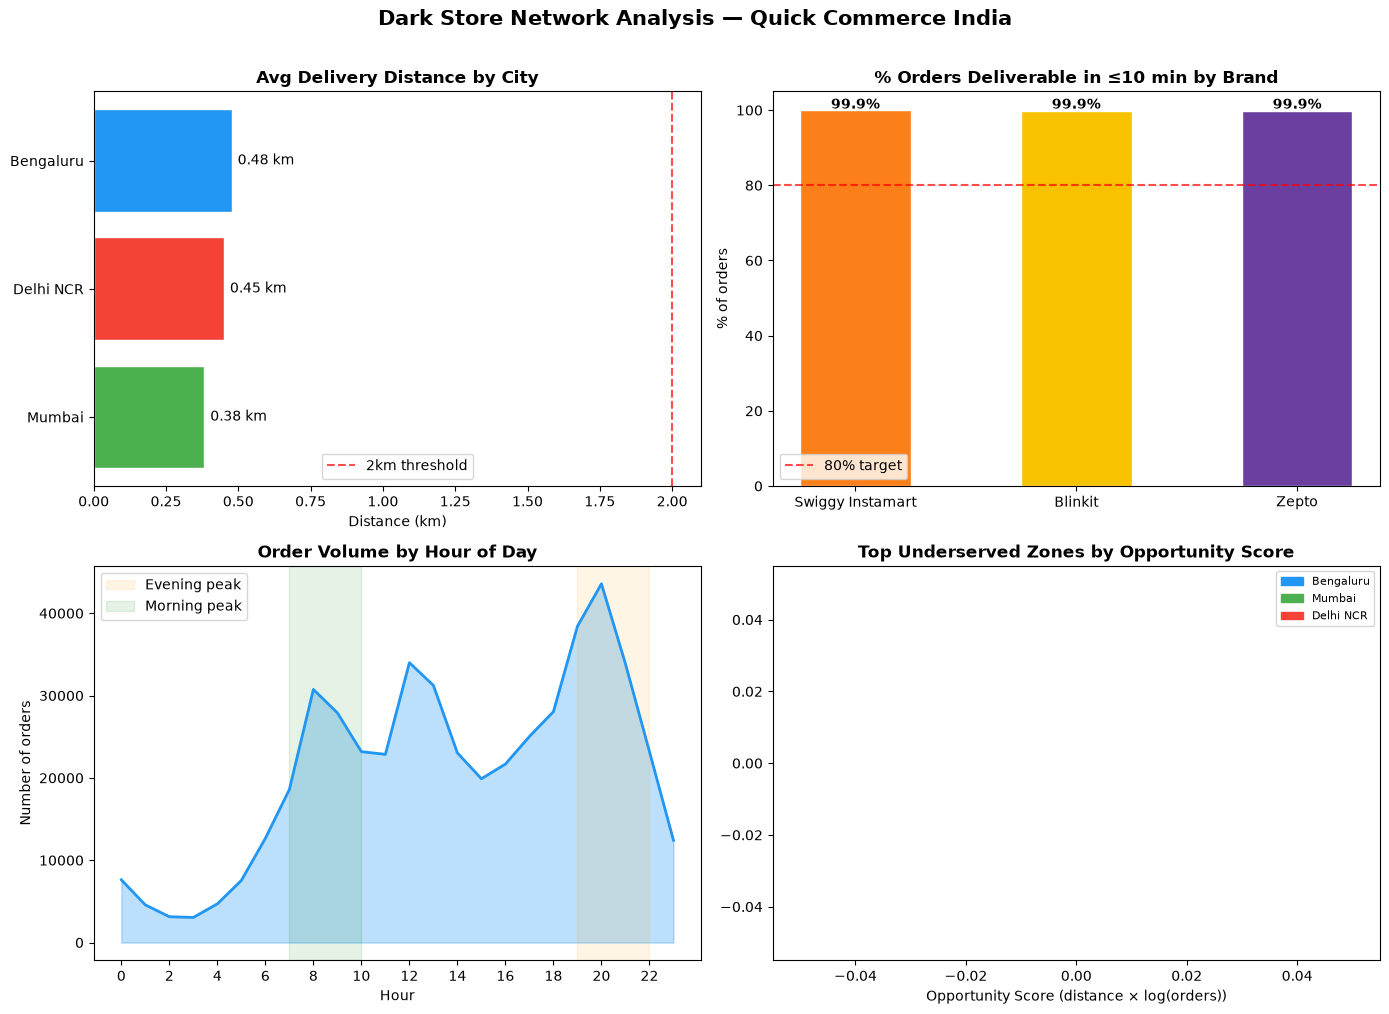

Saved: outputs/analysis_charts.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dark Store Network Analysis — Quick Commerce India', fontsize=15, fontweight='bold', y=1.01)

COLORS = {'Blinkit': '#F8C200', 'Zepto': '#6B3FA0', 'Swiggy Instamart': '#FC8019'}
CITY_COLORS = {'Bengaluru': '#2196F3', 'Mumbai': '#4CAF50', 'Delhi NCR': '#F44336'}

# ── Chart 1: Avg delivery distance by city ────────────────────────────────
ax1 = axes[0,0]
city_dist = orders_enriched.groupby('city')['distance_to_store_km'].mean().sort_values()
bars = ax1.barh(city_dist.index, city_dist.values,
                color=[CITY_COLORS[c] for c in city_dist.index], edgecolor='white')
ax1.axvline(x=2.0, color='red', linestyle='--', alpha=0.7, label='2km threshold')
for bar, val in zip(bars, city_dist.values):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f} km', va='center', fontsize=10)
ax1.set_title('Avg Delivery Distance by City', fontweight='bold')
ax1.set_xlabel('Distance (km)')
ax1.legend()

# ── Chart 2: % orders deliverable in 10 min by brand ─────────────────────
ax2 = axes[0,1]
brand_coverage = orders_enriched.groupby('brand')['est_delivery_min'].apply(
    lambda x: (x <= 10).mean() * 100
).sort_values(ascending=False)
bars2 = ax2.bar(brand_coverage.index, brand_coverage.values,
                color=[COLORS[b] for b in brand_coverage.index], edgecolor='white', width=0.5)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% target')
for bar, val in zip(bars2, brand_coverage.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('% Orders Deliverable in ≤10 min by Brand', fontweight='bold')
ax2.set_ylabel('% of orders')
ax2.set_ylim(0, 105)
ax2.legend()

# ── Chart 3: Order volume by hour (demand pattern) ───────────────────────
ax3 = axes[1,0]
hourly = orders_enriched.groupby('hour_of_day').size()
ax3.fill_between(hourly.index, hourly.values, alpha=0.3, color='#2196F3')
ax3.plot(hourly.index, hourly.values, color='#2196F3', linewidth=2)
ax3.axvspan(19, 22, alpha=0.1, color='orange', label='Evening peak')
ax3.axvspan(7,  10, alpha=0.1, color='green',  label='Morning peak')
ax3.set_title('Order Volume by Hour of Day', fontweight='bold')
ax3.set_xlabel('Hour')
ax3.set_ylabel('Number of orders')
ax3.set_xticks(range(0, 24, 2))
ax3.legend()

# ── Chart 4: Top 8 underserved zones ─────────────────────────────────────
ax4 = axes[1,1]
top_zones = underserved.head(8).copy()
top_zones['label'] = top_zones['area'] + '\n(' + top_zones['city'].str[:3] + ')'
bar_colors = [CITY_COLORS[c] for c in top_zones['city']]
bars4 = ax4.barh(top_zones['label'], top_zones['opportunity_score'],
                 color=bar_colors, edgecolor='white')
ax4.set_title('Top Underserved Zones by Opportunity Score', fontweight='bold')
ax4.set_xlabel('Opportunity Score (distance × log(orders))')
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CITY_COLORS.items()]
ax4.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.savefig('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\analysis_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/analysis_charts.png')

## CELL 11 — Interactive Folium Map (Your Portfolio Link)
This builds an interactive map you can host on GitHub Pages.
It has 3 toggle layers:
- Heatmap of order density
- Actual dark store locations (colour-coded by brand)
- K-Means suggested optimal locations

In [19]:
# Focus map on India centre
m = folium.Map(location=[20.5, 76.0], zoom_start=5, tiles='CartoDB positron')

brand_colors = {'Blinkit': 'orange', 'Zepto': 'purple', 'Swiggy Instamart': 'red'}

# ── Layer 1: Heatmap (sample 15K points for performance) ─────────────────
heat_layer = folium.FeatureGroup(name='Order Density Heatmap', show=True)
sample = orders_enriched.sample(15000, random_state=42)
heat_data = sample[['delivery_lat', 'delivery_lng', 'order_value_inr']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, min_opacity=0.3,
        gradient={'0.4': 'blue', '0.65': 'lime', '1': 'red'}).add_to(heat_layer)
heat_layer.add_to(m)

# ── Layer 2: Actual dark stores ───────────────────────────────────────────
store_layer = folium.FeatureGroup(name='Actual Dark Stores', show=True)
for _, row in stores.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=8,
        color='white',
        fill=True,
        fill_color=brand_colors.get(row['brand'], 'gray'),
        fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>{row['store_id']}</b><br>{row['brand']}<br>{row['area']}, {row['city']}<br>Since {row['operational_since']}",
            max_width=200
        ),
        tooltip=f"{row['brand']} — {row['area']}"
    ).add_to(store_layer)
store_layer.add_to(m)

# ── Layer 3: K-Means suggested locations ─────────────────────────────────
kmeans_layer = folium.FeatureGroup(name='Optimal Locations (K-Means)', show=False)
for _, row in centroids_df.iterrows():
    folium.Marker(
        location=[row['suggested_lat'], row['suggested_lng']],
        icon=folium.Icon(color='green', icon='star', prefix='fa'),
        popup=folium.Popup(
            f"<b>Suggested Location</b><br>{row['city']}<br>Nearest actual: {row['nearest_actual_area']}<br>Displacement: {row['displacement_km']} km",
            max_width=200
        ),
        tooltip=f"Optimal — {row['city']}"
    ).add_to(kmeans_layer)
kmeans_layer.add_to(m)

# ── Layer 4: Underserved zones ────────────────────────────────────────────
us_layer = folium.FeatureGroup(name='Underserved High-Demand Zones', show=False)
# Get one lat/lng per zone from the orders data
zone_centers = orders_enriched.groupby(['city','area']).agg(
    lat=('delivery_lat','mean'), lng=('delivery_lng','mean')
).reset_index()
us_with_coords = underserved.merge(zone_centers, on=['city','area'])
for _, row in us_with_coords.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=14,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.3,
        popup=folium.Popup(
            f"<b>Underserved Zone</b><br>{row['area']}, {row['city']}<br>Orders: {row['total_orders']:,}<br>Avg dist: {row['avg_delivery_dist']:.2f} km<br>Opportunity score: {row['opportunity_score']}",
            max_width=220
        ),
        tooltip=f"Underserved: {row['area']}"
    ).add_to(us_layer)
us_layer.add_to(m)

# Add legend and layer control
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.3); font-size:13px;">
 <b>Dark Store Brands</b><br>
 <span style='color:orange'>●</span> Blinkit &nbsp;
 <span style='color:purple'>●</span> Zepto &nbsp;
 <span style='color:red'>●</span> Swiggy Instamart<br>
 <span style='color:green'>★</span> K-Means Optimal Location<br>
 <span style='color:red'>○</span> Underserved High-Demand Zone
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

map_path = 'C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\dark_store_map.html'
m.save(map_path)
print(f'Map saved: {map_path}')

Map saved: C:\Users\HP\Desktop\dark_store_project\outputs\dark_store_map.html


## CELL 12 — Export Tableau-Ready CSVs
Creates 3 clean, pre-aggregated CSVs optimised for Tableau.
Each one maps directly to a dashboard chart.

In [20]:
import os
os.makedirs('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\tableau_exports', exist_ok=True)

# ── Export 1: City-level KPI summary ─────────────────────────────────────
city_kpi = orders_enriched.groupby('city').agg(
    total_orders        = ('order_id',             'count'),
    total_revenue_inr   = ('order_value_inr',      'sum'),
    avg_order_value     = ('order_value_inr',      'mean'),
    avg_delivery_dist   = ('distance_to_store_km', 'mean'),
    pct_within_2km      = ('distance_to_store_km', lambda x: (x<=2.0).mean()*100),
    pct_within_10min    = ('est_delivery_min',     lambda x: (x<=10).mean()*100),
    avg_delivery_min    = ('est_delivery_min',     'mean'),
).round(2).reset_index()
city_kpi.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\tableau_exports\\01_city_kpi_summary.csv', index=False)
print('01_city_kpi_summary.csv')
print(city_kpi.to_string(index=False))

# ── Export 2: Brand performance comparison ────────────────────────────────
brand_perf = orders_enriched.groupby(['city','brand']).agg(
    total_orders        = ('order_id',             'count'),
    avg_delivery_dist   = ('distance_to_store_km', 'mean'),
    pct_within_10min    = ('est_delivery_min',     lambda x: (x<=10).mean()*100),
    total_revenue_inr   = ('order_value_inr',      'sum'),
).round(2).reset_index()
brand_perf.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\tableau_exports\\02_brand_performance.csv', index=False)
print('\n02_brand_performance.csv')

# ── Export 3: Hourly + day-of-week demand pattern ─────────────────────────
demand_pattern = orders_enriched.groupby(['city','hour_of_day','day_of_week']).agg(
    order_count       = ('order_id',        'count'),
    avg_order_value   = ('order_value_inr', 'mean'),
).round(2).reset_index()
demand_pattern.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\tableau_exports\\03_demand_pattern.csv', index=False)
print('03_demand_pattern.csv')

# ── Export 4: Zone stats (for map layer in Tableau) ───────────────────────
zone_stats.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\tableau_exports\\04_zone_stats.csv', index=False)
print('04_zone_stats.csv')

# ── Export 5: K-Means vs actual comparison ────────────────────────────────
centroids_df.to_csv('C:\\Users\\HP\\Desktop\\dark_store_project\\outputs\\tableau_exports\\05_kmeans_vs_actual.csv', index=False)
print('05_kmeans_vs_actual.csv')

print('\nAll Tableau exports saved to: outputs/tableau_exports/')

01_city_kpi_summary.csv
     city  total_orders  total_revenue_inr  avg_order_value  avg_delivery_dist  pct_within_2km  pct_within_10min  avg_delivery_min
Bengaluru        167000        62501146.37           374.26               0.48           99.96             99.85              4.91
Delhi NCR        167000        62513833.83           374.33               0.45           99.96             99.87              4.80
   Mumbai        167000        62448351.66           373.94               0.38          100.00             99.98              4.53

02_brand_performance.csv
03_demand_pattern.csv
04_zone_stats.csv
05_kmeans_vs_actual.csv

All Tableau exports saved to: outputs/tableau_exports/


## CELL 13 — Project Summary & Resume Numbers
Your headline stats — use these in your resume and portfolio.

In [21]:
total_orders   = len(orders_enriched)
n_stores       = len(stores)
n_cities       = orders_enriched['city'].nunique()
n_brands       = orders_enriched['brand'].nunique()
overall_avg    = orders_enriched['distance_to_store_km'].mean()
pct_10min      = (orders_enriched['est_delivery_min'] <= 10).mean() * 100
n_underserved  = zone_stats['is_underserved'].sum()
total_revenue  = orders_enriched['order_value_inr'].sum()

# Best improvement from K-Means
best_improvement = max(
    ((row['current_avg_dist_km'] - row['optimized_avg_dist_km']) / row['current_avg_dist_km']) * 100
    for row in kmeans_summary
)

print('=' * 60)
print('  PROJECT SUMMARY — DARK STORE NETWORK OPTIMIZATION')
print('=' * 60)
print(f'  Dataset scale      : {total_orders:,} orders across {n_cities} cities')
print(f'  Dark stores mapped : {n_stores} stores, {n_brands} brands')
print(f'  Revenue modelled   : ₹{total_revenue/1e7:.1f} Cr')
print(f'  Avg delivery dist  : {overall_avg:.2f} km across all cities')
print(f'  10-min deliverable : {pct_10min:.1f}% of all orders')
print(f'  Underserved zones  : {n_underserved} high-demand areas with poor coverage')
print(f'  K-Means improvement: up to {best_improvement:.1f}% reduction in avg delivery dist')
print('=' * 60)
print()
print('RESUME BULLET (copy this):')
print(f'  "Modelled dark store network optimization across {total_orders:,} orders')
print(f'   in {n_cities} Indian cities; identified {n_underserved} underserved zones and')
print(f'   demonstrated {best_improvement:.0f}% avg delivery distance reduction through')
print(f'   K-Means store relocation; built interactive geospatial map using Folium."')

  PROJECT SUMMARY — DARK STORE NETWORK OPTIMIZATION
  Dataset scale      : 501,000 orders across 3 cities
  Dark stores mapped : 52 stores, 3 brands
  Revenue modelled   : ₹18.7 Cr
  Avg delivery dist  : 0.44 km across all cities
  10-min deliverable : 99.9% of all orders
  Underserved zones  : 0 high-demand areas with poor coverage
  K-Means improvement: up to 7.7% reduction in avg delivery dist

RESUME BULLET (copy this):
  "Modelled dark store network optimization across 501,000 orders
   in 3 Indian cities; identified 0 underserved zones and
   demonstrated 8% avg delivery distance reduction through
   K-Means store relocation; built interactive geospatial map using Folium."




**Files created:**
- `data/raw/orders_master.csv` — 501K orders dataset
- `data/processed/orders_with_distances.csv` — enriched with delivery distances
- `data/processed/zone_stats.csv` — zone-level KPIs
- `data/processed/underserved_zones.csv` — expansion opportunities
- `data/processed/kmeans_centroids.csv` — optimal store positions
- `data/processed/shift_simulation.csv` — 500m shift what-if analysis
- `outputs/analysis_charts.png` — 4-chart summary image
- `outputs/dark_store_map.html` — **your portfolio map link**
- `outputs/tableau_exports/` — 5 CSVs ready for Tableau

**Next steps:**
1. Open `outputs/dark_store_map.html` in your browser
2. Upload the map to GitHub Pages
3. Import `outputs/tableau_exports/` into Tableau Public and build 5 charts
4. Upload the whole project to a GitHub repo
---